# Client Transaction Risk Analytics - Model Experimentation
Use this notebook to experiment with different algorithms and hyperparameters. Compare their results side-by-side below!

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump

## 1. Load Data & Feature Engineering

In [2]:
# Load data (adjusting path because this notebook is inside the 'notebooks' folder)
data = pd.read_csv('../data/modelData_transaction.csv')

# Ensure transaction_date is datetime type
data['transaction_date'] = pd.to_datetime(data['transaction_date'], errors="coerce")

# Calculate transaction velocity per absolute hour bucket per account
data['tx_date_only'] = data['transaction_date'].dt.date
data['tx_hour_only'] = data['transaction_date'].dt.hour

data['transactions_this_hour'] = data.groupby(
    ['account_id', 'tx_date_only', 'tx_hour_only']
)['account_id'].transform('count')

# Drop temporary date/hour columns used for grouping
data = data.drop(columns=['tx_date_only', 'tx_hour_only'])

X = data.drop(columns=["is_fraud", "transaction_id", "account_id", "merchant", "merchant_category"], errors="ignore")
Y = data['is_fraud']

# Convert date column to numerical features
if "transaction_date" in X.columns:
    X["tx_year"] = X["transaction_date"].dt.year
    X["tx_month"] = X["transaction_date"].dt.month
    X["tx_day"] = X["transaction_date"].dt.day
    X["tx_weekday"] = X["transaction_date"].dt.weekday
    X = X.drop(columns=["transaction_date"])
    
X = X.fillna(X.median(numeric_only=True))
X.head()

,amount,merchant_lat,merchant_long,transactions_this_hour,tx_year,tx_month,tx_day,tx_weekday
0,9.67,34.276429,-99.588812,1.0,2019.0,10.0,5.0,5.0
1,222.73,29.105249,-81.709732,1.0,2019.0,7.0,10.0,2.0
2,69.25,32.678682,-90.750526,2.0,2019.0,12.0,8.0,6.0
3,56.01,39.448555,-75.420177,1.0,2019.0,6.0,7.0,4.0
4,92.84,45.025386,-72.986049,1.0,2019.0,2.0,12.0,1.0


## 2. Train-Test Split & Scaling

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Experiment A: Logistic Regression (Balanced)

In [8]:
model = LogisticRegression()
model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train_scaled, Y_train)
model_balanced.fit(X_train_scaled, Y_train)

y_pred = model.predict(X_test_scaled)
y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Logistic Regression (Without Class Balance) Performance:\n")
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred, digits=4))

print("Logistic Regression (Class Balanced) Performance:\n")
print(confusion_matrix(Y_test, y_pred_balanced))
print(classification_report(Y_test, y_pred_balanced, digits=4))

Logistic Regression (Without Class Balance) Performance:

[[177658      0      0]
 [   180   8978     18]
 [     0    192     12]]
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995    177658
           1     0.9791    0.9784    0.9787      9176
           2     0.4000    0.0588    0.1026       204

    accuracy                         0.9979    187038
   macro avg     0.7927    0.6791    0.6936    187038
weighted avg     0.9974    0.9979    0.9975    187038

Logistic Regression (Class Balanced) Performance:

[[176241   1417      0]
 [     2   7888   1286]
 [     0     19    185]]
              precision    recall  f1-score   support

           0     1.0000    0.9920    0.9960    177658
           1     0.8460    0.8596    0.8528      9176
           2     0.1258    0.9069    0.2209       204

    accuracy                         0.9854    187038
   macro avg     0.6572    0.9195    0.6899    187038
weighted avg     0.9915    0.9854    0

## 4. Experiment B: Random Forest (Alternative)
Tree based models often perform much better on highly imbalanced data natively.

In [4]:
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_rf.fit(X_train, Y_train) # Note: Random Forests do not strictly require scaled data

y_pred_rf = model_rf.predict(X_test)

print("Random Forest Performance:\n")
print(confusion_matrix(Y_test, y_pred_rf))
print(classification_report(Y_test, y_pred_rf, digits=4))

Random Forest Performance:

[[177658      0      0]
 [     2   9171      3]
 [     0     15    189]]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    177658
           1     0.9984    0.9995    0.9989      9176
           2     0.9844    0.9265    0.9545       204

    accuracy                         0.9999    187038
   macro avg     0.9942    0.9753    0.9845    187038
weighted avg     0.9999    0.9999    0.9999    187038



In [6]:
from xgboost import XGBClassifier  
model_xgb = XGBClassifier(
      n_estimators=300,
      learning_rate=0.05,
      max_depth=6,
      subsample=0.8,
      colsample_bytree=0.8,
      random_state=42,
      eval_metric='mlogloss'
)
model_xgb.fit(X_train, Y_train)
y_pred_xgb = model_xgb.predict(X_test)
print("XGBoost Performance")
print(confusion_matrix(Y_test, y_pred_xgb))
print(classification_report(Y_test, y_pred_xgb, digits=4))

XGBoost Performance
[[177507    151      0]
 [    10   9165      1]
 [     0     16    188]]
              precision    recall  f1-score   support

           0     0.9999    0.9992    0.9995    177658
           1     0.9821    0.9988    0.9904      9176
           2     0.9947    0.9216    0.9567       204

    accuracy                         0.9990    187038
   macro avg     0.9923    0.9732    0.9822    187038
weighted avg     0.9991    0.9990    0.9991    187038



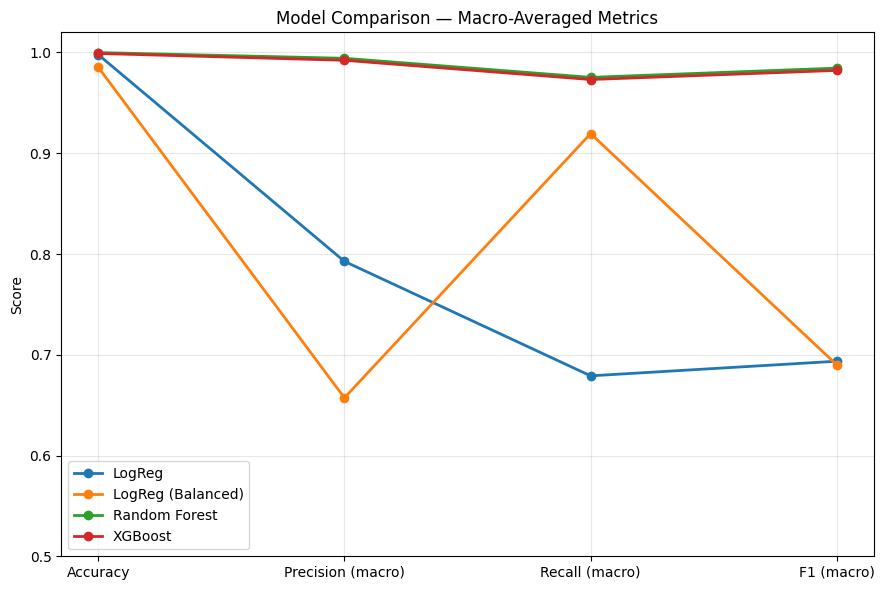

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect predictions from the 4 trained models
predictions = {
    "LogReg": y_pred,
    "LogReg (Balanced)": y_pred_balanced,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
}

metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]

# Compute scores for each model
scores = {}
for name, preds in predictions.items():
    scores[name] = [
        accuracy_score(Y_test, preds),
        precision_score(Y_test, preds, average="macro", zero_division=0),
        recall_score(Y_test, preds, average="macro", zero_division=0),
        f1_score(Y_test, preds, average="macro", zero_division=0),
    ]

# Plot
plt.figure(figsize=(9, 6))
for name, values in scores.items():
    plt.plot(metrics, values, marker="o", linewidth=2, label=name)

plt.ylim(0.5, 1.02)
plt.ylabel("Score")
plt.title("Model Comparison — Macro-Averaged Metrics")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()